In [1]:
from google.colab import drive, files
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az

Sources:
1.   https://colab.research.google.com/github/pymc-devs/pymc-examples/blob/main/examples/mixture_models/dirichlet_mixture_of_multinomials.ipynb
2.   https://www.statisticshowto.com/dirichlet-distribution/




In [3]:
files.upload()


Saving data_pull.py to data_pull.py


{'data_pull.py': b'import requests\r\nimport pandas as pd\r\n\r\n########### Crop Data\r\n\r\ndef crop_pull():\r\n        \r\n    key = \'3C7B7C44-4D80-3975-AF68-2423CD934AA5\'\r\n\r\n    url = "https://quickstats.nass.usda.gov/api/api_GET/"\r\n\r\n    params = {\r\n        "key": key,\r\n        "source_desc": "SURVEY",\r\n        "sector_desc": "CROPS",\r\n        "commodity_desc": "HAY",\r\n        "statisticcat_desc": "CONDITION",\r\n        "agg_level_desc": "STATE",\r\n        "state_alpha": "RI",\r\n        "freq_desc": "WEEKLY",\r\n        "year__GE": "2015"\r\n    }\r\n\r\n    r = requests.get(url, params=params)\r\n    r.raise_for_status()\r\n    data = r.json()["data"]   \r\n\r\n    df = pd.DataFrame(data)\r\n\r\n    data = df.drop(columns = [\'county_code\', \'country_code\', \'watershed_code\', \'statisticcat_desc\',\r\n        \'domaincat_desc\', \'load_time\', \'commodity_desc\', \'source_desc\',\r\n        \'short_desc\', \'region_desc\', \'prodn_practice_desc\', \'year

In [5]:
!python data_pull.py

In [6]:
x_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Bayesian Stats/Project/weather_data.csv')
x_df.set_index('date', inplace=True)
y_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Bayesian Stats/Project/crop_data.csv')
y_df.set_index('date', inplace=True)

x_df.drop('SNOW', axis=1, inplace=True)
x_wd = x_df.to_numpy()

x_mean = x_wd.mean(axis=0)
x_std = x_wd.std(axis=0)
x_wd = (x_wd-x_mean)/x_std

y_cd = y_df.to_numpy()

intercept = np.ones((x_wd.shape[0], 1))

x = np.hstack((intercept, x_wd))



In [7]:
y= y_cd + 1e-6 ###remove all 0s from observed
y= y/y.sum(axis=1, keepdims=True) ###renormalize to sum to 1

p = x.shape[1] #predictors
k = y.shape[1] #conditions

with pm.Model() as dir_m:
    beta = pm.Normal('beta', 0, .5, shape=(k,p))
    e = x @ beta.T
    alpha = pm.Deterministic('alpha',pm.math.exp(e) + 1e-6) ###add small variance to limit 0s

    lik = pm.Dirichlet('lik', a=alpha, observed = y)

    trace = pm.sample(2000, tune=1000, target_accept=.9)



Output()

In [8]:
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"alpha[0, 0]",0.084,0.028,0.036,0.137,0.000,0.001,7894.0,3089.0,1.0
"alpha[0, 1]",0.382,0.128,0.175,0.632,0.002,0.002,5324.0,3119.0,1.0
"alpha[0, 2]",0.429,0.130,0.210,0.678,0.002,0.002,6432.0,3306.0,1.0
"alpha[0, 3]",0.084,0.026,0.038,0.132,0.000,0.000,6040.0,2828.0,1.0
"alpha[0, 4]",0.071,0.021,0.034,0.110,0.000,0.000,6792.0,2911.0,1.0
...,...,...,...,...,...,...,...,...,...
"beta[4, 1]",-0.061,0.111,-0.260,0.153,0.001,0.002,6549.0,2890.0,1.0
"beta[4, 2]",0.090,0.127,-0.159,0.315,0.002,0.002,5680.0,3256.0,1.0
"beta[4, 3]",0.013,0.394,-0.734,0.741,0.005,0.006,5588.0,2857.0,1.0
"beta[4, 4]",0.003,0.376,-0.707,0.714,0.005,0.006,5171.0,3151.0,1.0


array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

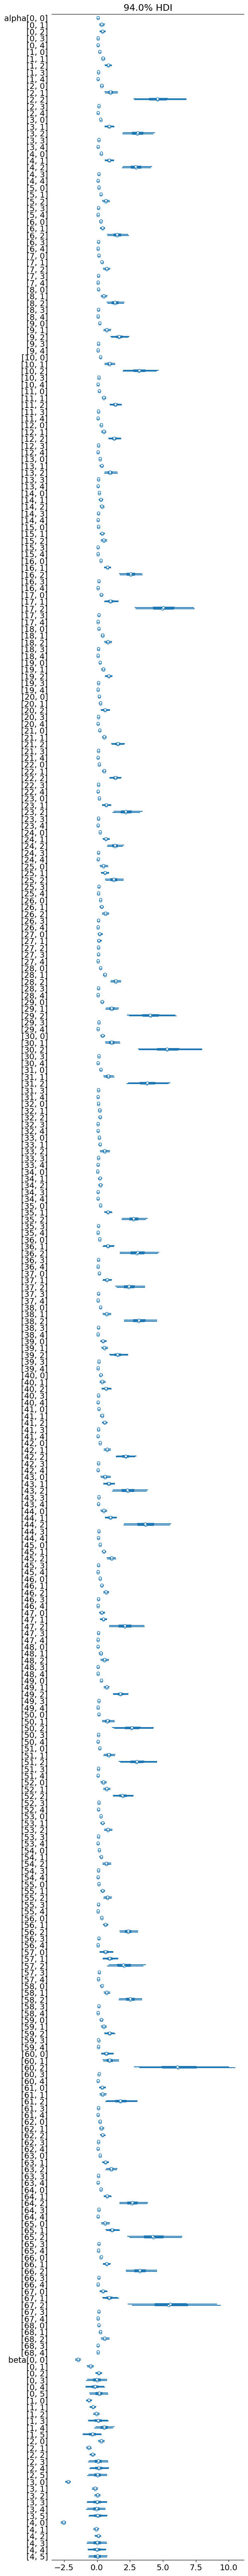

In [ ]:
az.plot_forest(trace)

This shows that throughout this data, the $\beta$ values show which weather conditions are most significant to crop condition. However, based on almost all HDIs, there is little confidence that any selected features offer siginficant impact. This could be due to a smaller dataset (69 observations, monthly from 2015-2024 (MAY-NOV)), and highly correlated weather variables (TMIN, TMAX, TAVG). Signal to noise ratio might be to low to interpret meaninful signals.

Lets remove TAVG and keep TMIN/TMAX to see any improvement

In [9]:
x_df.drop('TAVG', axis=1, inplace=True)
x_wd = x_df.to_numpy()

x_mean = x_wd.mean(axis=0)
x_std = x_wd.std(axis=0)
x_wd = (x_wd-x_mean)/x_std
intercept = np.ones((x_wd.shape[0], 1))
x = np.hstack((intercept, x_wd))

y_cd = y_df.to_numpy()
y= y_cd + 1e-6 ###remove all 0s from observed
y= y/y.sum(axis=1, keepdims=True) ###renormalize to sum to 1

p = x.shape[1] #predictors
k = y.shape[1] #conditions

with pm.Model() as dir_m:
    beta = pm.Normal('beta', 0, .5, shape=(k,p))
    e = x @ beta.T
    alpha = pm.Deterministic('alpha',pm.math.exp(e) + 1e-6) ###add small offset to limit 0s

    lik = pm.Dirichlet('lik', a=alpha, observed = y)

    trace_dir = pm.sample(2000, tune=1000, target_accept=.9)





Output()

In [10]:
az.summary(trace_dir)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"alpha[0, 0]",0.083,0.028,0.036,0.136,0.000,0.001,5342.0,3374.0,1.0
"alpha[0, 1]",0.380,0.127,0.177,0.625,0.002,0.003,4765.0,3003.0,1.0
"alpha[0, 2]",0.426,0.129,0.198,0.664,0.002,0.002,5994.0,2981.0,1.0
"alpha[0, 3]",0.084,0.026,0.042,0.135,0.000,0.001,6319.0,2822.0,1.0
"alpha[0, 4]",0.071,0.021,0.037,0.111,0.000,0.000,6152.0,3423.0,1.0
...,...,...,...,...,...,...,...,...,...
"beta[4, 0]",-2.537,0.110,-2.746,-2.332,0.001,0.002,5905.0,2869.0,1.0
"beta[4, 1]",-0.063,0.113,-0.273,0.143,0.001,0.002,6435.0,3137.0,1.0
"beta[4, 2]",0.093,0.130,-0.153,0.332,0.002,0.002,5661.0,3175.0,1.0
"beta[4, 3]",0.010,0.321,-0.599,0.579,0.005,0.005,4585.0,3051.0,1.0


Similary results to the last trace. Removing TAVG from x values did not signficantly effect the outcome. Potentially reworking the data to include more than 69 observations is the next step.

I had troubles reworking my API calls to include weekly data and/or return more than the max 1000 rows of data prior to processing. To adjust, I have added additional x columns to see if there are additional relationships or

In [30]:
###### With additional X Columns
x_df = pd.read_csv('/content/weather_dataV2.csv')
x_df.set_index('date', inplace=True)
y_df = pd.read_csv('/content/crop_dataV2.csv')
y_df.set_index('date', inplace=True)

x_df.drop('SNOW', axis=1, inplace=True)
x_wd = x_df.to_numpy()

x_mean = x_wd.mean(axis=0)
x_std = x_wd.std(axis=0)
x_wd = (x_wd-x_mean)/x_std

y_cd = y_df.to_numpy()

intercept = np.ones((x_wd.shape[0], 1))

x = np.hstack((intercept, x_wd))

y= y_cd + 1e-6 ###remove all 0s from observed
y= y/y.sum(axis=1, keepdims=True) ###renormalize to sum to 1

p = x.shape[1] #predictors
k = y.shape[1] #conditions

with pm.Model() as dir_m:
    beta = pm.Normal('beta', 0, .5, shape=(k,p))
    e = x @ beta.T
    alpha = pm.Deterministic('alpha',pm.math.exp(e) + 1e-6) ###add small variance to limit 0s

    lik = pm.Dirichlet('lik', a=alpha, observed = y)

    trace_dir = pm.sample(2000, tune=1000, target_accept=.9, idata_kwargs={'log_likelihood':True}, return_inferencedata=True)



Output()

In [13]:
az.summary(trace_dir)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"alpha[0, 0]",0.102,0.031,0.048,0.160,0.000,0.001,6064.0,2731.0,1.0
"alpha[0, 1]",0.284,0.087,0.139,0.449,0.001,0.001,4247.0,3286.0,1.0
"alpha[0, 2]",0.419,0.121,0.221,0.653,0.002,0.002,6042.0,3405.0,1.0
"alpha[0, 3]",0.099,0.031,0.049,0.159,0.000,0.001,6227.0,3572.0,1.0
"alpha[0, 4]",0.077,0.022,0.038,0.117,0.000,0.000,5234.0,3233.0,1.0
...,...,...,...,...,...,...,...,...,...
"beta[4, 3]",-0.333,0.314,-0.894,0.276,0.005,0.005,3405.0,2724.0,1.0
"beta[4, 4]",-0.041,0.231,-0.488,0.375,0.003,0.004,4801.0,3036.0,1.0
"beta[4, 5]",-0.078,0.335,-0.740,0.514,0.006,0.005,2834.0,2755.0,1.0
"beta[4, 6]",0.121,0.122,-0.117,0.341,0.001,0.002,6888.0,3142.0,1.0


All feature betas still have HDI values that cross 0, indicating that there is no one single weather feature that has an impact on crop quality. Of course, it is common knowledge that weather conditions are probably some of the MOST IMPORTANT predictors when it comes to crop quality, so I believe this can be attributed to the collinearity of the covariates, data set sample size, or the Alpha and Beta values effect on the Dirichlet Distribution. I've almost exhausted all options for gathering additional data given the API constraints, so the next step is going to be to engineer some of the features or further experiment with a different distribution to inspect for different results.

In [116]:
###Multinomial logit model
weather_new = pd.read_csv('/content/weather_dataV2.csv')
weather_new = weather_new.drop('SNOW', axis=1)
x = weather_new.set_index('date').to_numpy()
print(weather_new)
x_mean = x.mean(axis=0)
x_std = x.std(axis=0)
x = (x-x_mean)/x_std
intercept = np.ones((x.shape[0], 1))
x = np.hstack((intercept, x))

n, p = x.shape

crop_new = pd.read_csv('/content/crop_dataV2.csv')
crop_new.set_index('date', inplace=True)
y = (crop_new/100) * 1000 #pseudo count of counts per 1000 crops
y = y.round().astype('int64')
print(crop_new)
y = y.to_numpy()

k = y.shape[1]


with pm.Model() as multi_logit:
  beta = pm.Normal('beta', 0,1, shape = (p,k))
  v = x @ beta

  p = pm.Deterministic('prob', pm.math.softmax(v, axis=1))

  lik = pm.Multinomial('lik', n = y.sum(axis=1), p=p, observed=y)

  trace_ml = pm.sample(2000, tune=1000, idata_kwargs={'log_likelihood':True}, return_inferencedata = True)



          date  AWND   CLDD  EMNT  EMXT   HTDD  PRCP  TAVG
0   2015-05-01   9.6   61.0  37.0  86.0  125.0  3.69  62.9
1   2015-06-01   8.5  116.0  46.0  87.0   75.0  5.35  66.4
2   2015-07-01   7.4  296.0  57.0  93.0    0.0  2.35  74.6
3   2015-08-01   7.8  307.0  58.0  91.0    0.0  2.78  74.9
4   2015-09-01   7.6  147.0  42.0  97.0   24.0  3.19  69.1
..         ...   ...    ...   ...   ...    ...   ...   ...
64  2024-07-01   7.8  318.0  58.0  91.0    0.0  3.57  75.3
65  2024-08-01   6.9  194.0  52.0  91.0    5.0  4.85  71.1
66  2024-09-01   7.6   40.0  50.0  84.0   46.0  1.86  64.8
67  2024-10-01   6.9    0.0  32.0  81.0  300.0  0.98  55.3
68  2024-11-01   8.9    4.0  27.0  80.0  533.0  2.57  47.4

[69 rows x 8 columns]
            PCT EXCELLENT  PCT FAIR  PCT GOOD  PCT POOR  PCT VERY POOR
date                                                                  
2015-05-01          0.000    15.000    85.000     0.000            0.0
2015-06-01          0.000    18.750    81.250     0.000 

Output()

In [22]:
az.summary(trace_ml.posterior['beta'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"beta[0, 0]",0.454,0.444,-0.365,1.307,0.009,0.008,2686.0,2409.0,1.0
"beta[0, 1]",1.063,0.444,0.269,1.938,0.008,0.008,2749.0,2457.0,1.0
"beta[0, 2]",2.178,0.444,1.383,3.054,0.009,0.008,2689.0,2456.0,1.0
"beta[0, 3]",-1.191,0.445,-2.000,-0.329,0.009,0.008,2693.0,2345.0,1.0
"beta[0, 4]",-2.537,0.449,-3.403,-1.726,0.009,0.008,2683.0,2363.0,1.0
"beta[1, 0]",-0.158,0.442,-0.991,0.661,0.007,0.008,3631.0,2469.0,1.0
"beta[1, 1]",0.279,0.442,-0.563,1.095,0.007,0.008,3631.0,2595.0,1.0
"beta[1, 2]",0.029,0.442,-0.805,0.849,0.007,0.008,3633.0,2668.0,1.0
"beta[1, 3]",-0.116,0.442,-0.945,0.720,0.007,0.008,3638.0,2491.0,1.0
"beta[1, 4]",0.032,0.443,-0.838,0.836,0.007,0.008,3621.0,2644.0,1.0



*  Beta(0,:) = Intercept
*  Beta(1,:) = Averagre Wind Speed
*  Beta(2,:) = Cooling Degree Days
*  Beta(3,:) = Extreme Min Temp
*  Beta(4,:) = Extreme Max Temp
*  Beta(5,:) = Heating Degree Days
*  Beta(6,:) = Precipitation
*  Beta(7,:) = Snowfall
*  Beta(8,:) = Average Temp

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

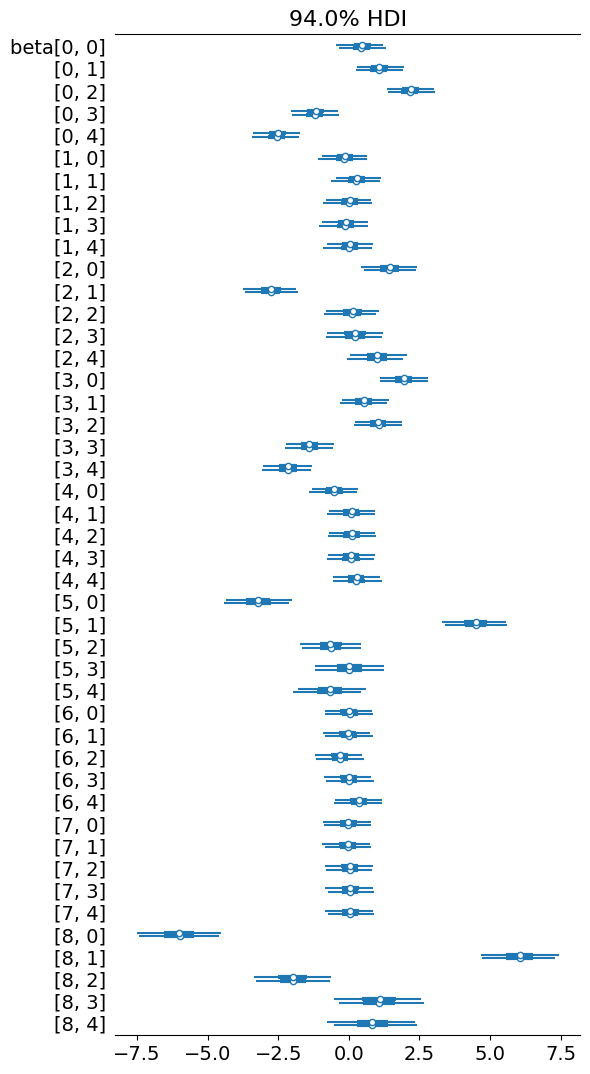

In [26]:
az.plot_forest(trace_ml.posterior['beta'])

Significantly better results comparing the Dirichlet and MultiLogit model without doing any feature engineering. It does appear there are significant impacts by a few factors on mostly PCT EXCELLENT and PCT FAIR conditions.

In [117]:
az.compare({'mlogit':trace_ml, 'dirichlet':trace_dir}, ic='loo',scale = 'deviance')

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
dirichlet,0,-3206.509814,40.765707,0.000000,1.000000e+00,230.303433,0.000000,True,deviance
mlogit,1,31627.694051,1987.987553,34834.203865,5.190657e-10,3870.279183,3938.293582,True,deviance


Although the Multi Logit model offered more interpretable results with HDIs concluding that certain weather features affected crop condition more significantly than others, the LOO comparison suggests that the Dirchlet model offers a better fit and better predictive power in comparison.

Going to pull additional x and y data to test the predicitive power of each model using RMSE.

In [35]:
def crop_pull():

    key = '3C7B7C44-4D80-3975-AF68-2423CD934AA5'

    url = "https://quickstats.nass.usda.gov/api/api_GET/"

    params = {
        "key": key,
        "source_desc": "SURVEY",
        "sector_desc": "CROPS",
        "commodity_desc": "HAY",
        "statisticcat_desc": "CONDITION",
        "agg_level_desc": "STATE",
        "state_alpha": "RI",
        "freq_desc": "WEEKLY",
        "year__GE": "2024"
    }

    r = requests.get(url, params=params)
    r.raise_for_status()
    data = r.json()["data"]

    df = pd.DataFrame(data)

    data = df.drop(columns = ['county_code', 'country_code', 'watershed_code', 'statisticcat_desc',
        'domaincat_desc', 'load_time', 'commodity_desc', 'source_desc',
        'short_desc', 'region_desc', 'prodn_practice_desc', 'year', 'CV (%)',
        'location_desc', 'county_ansi', 'asd_code', 'sector_desc',
        'state_fips_code', 'end_code', 'zip_5', 'reference_period_desc',
        'begin_code', 'state_ansi', 'domain_desc',
        'agg_level_desc', 'group_desc', 'congr_district_code', 'watershed_desc',
        'util_practice_desc', 'asd_desc', 'state_alpha', 'class_desc',
        'state_name', 'freq_desc', 'country_name', 'county_name'])

    data['week_ending'] = pd.to_datetime(data['week_ending'])

    data['date'] = data['week_ending']
    data['quality'] = data['unit_desc']
    data['Value'] = pd.to_numeric(data['Value'])
    data.drop(columns = ['week_ending', 'unit_desc'], inplace=True)

    crop_data = data.pivot_table(index='date', columns='quality', values='Value', aggfunc='mean').reset_index()

    return crop_data


In [36]:
def weather_pull():

    key = 'KmmwiCbiXtqCkSHgXDaoiZPvLIQUwrwT'

    url = 'https://www.ncei.noaa.gov/cdo-web/api/v2/data'

    headers = {'token': key}

    params = {
        "datasetid": "GSOM",
        "stationid": "GHCND:USW00014765", ###this is PVD, RI
        "datatypeid": ['TAVG', 'PRCP', 'SNOW', 'AWND', 'EMXT', 'EMNT', 'CLDD', 'HTDD'],
        "startdate": "2025-01-01",
        "enddate": "2025-12-31",
        "limit": 1000, ###will return max of 1000 rows regardless of date range
        "units": "standard",
    }

    r = requests.get(url=url, params=params, headers=headers).json()

    data = pd.DataFrame(r['results'])

    weather_data = data.drop(['station','attributes'], axis =1)
    weather_data['date'] = pd.to_datetime(weather_data['date'])
    weather_data = weather_data.pivot(index='date', columns='datatype', values='value')

    return weather_data

In [103]:
import requests

crop_data = crop_pull()
weather_data = weather_pull()

crop_data['date'] = pd.to_datetime(crop_data['date'])
crop_data['date'] = crop_data['date'].dt.to_period('M').dt.to_timestamp()

crop_data = crop_data.groupby('date').mean()
crop_data.index = pd.to_datetime(crop_data.index)
weather_data.drop('SNOW', axis=1, inplace=True)

weather_data.index = pd.to_datetime(weather_data.index)

idx = crop_data.index.intersection(weather_data.index)

cd = crop_data.loc[idx]
wd = weather_data.loc[idx]

test_y = cd.fillna(0)
test_y = test_y.to_numpy()
test_y = test_y/100
test_x = wd.fillna(0)
print('Weather Data (x)\n',test_x)
print('Crop Data (y)\n',test_y)

test_x = test_x.to_numpy()
x_mean = test_x.mean(axis=0)
x_std = test_x.std(axis=0)
test_x = (test_x-x_mean)/x_std

intercept = np.ones((test_x.shape[0], 1))
test_x = np.hstack((intercept, test_x))
test_x = np.nan_to_num(test_x, nan=0)


Weather Data (x)
 datatype    AWND   CLDD  EMNT   EMXT   HTDD  PRCP  TAVG
date                                                   
2025-05-01   8.9    6.0  41.0   79.0  175.0  8.05  59.6
2025-06-01   7.8  184.0  49.0  100.0   27.0  1.15  70.2
2025-07-01   7.8  330.0  56.0   97.0    0.0  5.09  75.6
2025-08-01   0.0  157.0  51.0   91.0   11.0  2.68  69.7
2025-09-01   0.0   69.0  45.0   83.0   33.0  6.24  66.2
Crop Data (y)
 [[0.05    0.8     0.05    0.05    0.05   ]
 [0.035   0.495   0.465   0.005   0.     ]
 [0.1     0.26875 0.63125 0.      0.     ]
 [0.161   0.075   0.764   0.      0.     ]
 [0.2425  0.12625 0.63125 0.      0.     ]]


Test X data has been processed and is ready to be fed into Dirichlet and Multi Logit models

In [105]:
###Dirichlet
from scipy.special import softmax
n, p = test_x.shape

beta_d = trace_dir.posterior['beta'].values
chain, draw, k, p = beta_d.shape
s = beta_d.shape[0] * beta_d.shape[1]
beta_d = beta_d.reshape(s,k,p)

preds = np.empty((s, n, k))
for index,b in enumerate(beta_d):
  e = test_x @ b.T
  p = softmax(e, axis=1)
  preds[index] = p

preds_dir = preds.mean(axis=0)
print(preds_dir)
print(test_y)

[[0.16463385 0.27675134 0.36329519 0.10843211 0.08688751]
 [0.04097025 0.25113957 0.66004258 0.02855324 0.01929436]
 [0.07259932 0.26876758 0.55155622 0.06140522 0.04567166]
 [0.0967535  0.15097106 0.71770303 0.02108993 0.01348247]
 [0.17856747 0.18252592 0.55981383 0.04855112 0.03054166]]
[[0.05    0.8     0.05    0.05    0.05   ]
 [0.035   0.495   0.465   0.005   0.     ]
 [0.1     0.26875 0.63125 0.      0.     ]
 [0.161   0.075   0.764   0.      0.     ]
 [0.2425  0.12625 0.63125 0.      0.     ]]


In [121]:
###Multi Logit
n, p_x = test_x.shape
beta_ml = trace_ml.posterior['beta'].values

chain, draw, p, k = beta_ml.shape
s = chain * draw
beta_ml = beta_ml.reshape(s, p, k)

preds_ml = np.empty((s, n, k))
for draw in range(s):
  b = beta_ml[draw]
  e = test_x @ b
  p = softmax(e, axis=1)

  preds_ml[draw] = p

preds_ml = preds_ml.mean(axis=0)
print(preds_ml)
print(test_y)

[[0.03560578 0.69378217 0.25902635 0.00997007 0.00161564]
 [0.03017513 0.22938938 0.70838224 0.02441519 0.00763805]
 [0.02430524 0.69739952 0.25981901 0.01220475 0.00627149]
 [0.28138256 0.03314188 0.6748567  0.00905986 0.00155898]
 [0.42265958 0.01751727 0.51923095 0.03178725 0.00880495]]
[[0.05    0.8     0.05    0.05    0.05   ]
 [0.035   0.495   0.465   0.005   0.     ]
 [0.1     0.26875 0.63125 0.      0.     ]
 [0.161   0.075   0.764   0.      0.     ]
 [0.2425  0.12625 0.63125 0.      0.     ]]


Now I have predicted y values for each model and can compare it against the out of sample y data

In [135]:
from sklearn import metrics

rmse_dir = metrics.mean_squared_error(test_y, preds_dir)
rmse_ml = metrics.mean_squared_error(test_y, preds_ml)

rmse_ml_classes = np.sqrt(((preds_ml - test_y)**2).mean(axis=0))
rmse_dir_classes = np.sqrt(((preds_dir - test_y)**2).mean(axis=0))

MAE_dir = metrics.mean_absolute_error(test_y, preds_dir)
MAE_ml = metrics.mean_absolute_error(test_y, preds_ml)

MAE_dir_classes = np.abs(preds_dir - test_y).mean(axis=0)
MAE_ml_classes = np.abs(preds_ml - test_y).mean(axis=0)
print(f'RMSE for the Dirichlet Model is {rmse_dir}\nRMSE for the Multi Logit model is {rmse_ml}')

print(f'RMSE for each category for Dirichlet Model is {rmse_dir_classes}\nRMSE for each category for Multi Logit Model is {rmse_ml_classes}')

print(f'MAE foe Dirichlet Model is {MAE_dir}\nMAE for Multi Logit Model is {MAE_ml}')

print(f'MAE for each category for Dirichlet Model is {MAE_dir_classes}\nMAE for each category for Multi Logit Model in {MAE_ml_classes}')

RMSE for the Dirichlet Model is 0.02118424846140208
RMSE for the Multi Logit model is 0.023967133690859063
RMSE for each category for Dirichlet Model is [0.06654674 0.26160874 0.1730856  0.04591659 0.03141156]
RMSE for each category for Multi Logit Model is [0.10286847 0.23628227 0.22864064 0.02538035 0.02244404]
MAE foe Dirichlet Model is 0.08960925811510285
MAE for Multi Logit Model is 0.10226726205160863
MAE for each category for Dirichlet Model is [0.05523676 0.17987473 0.14115294 0.04260633 0.02917553]
MAE for each category for Multi Logit Model in [0.0790912  0.19021376 0.20500039 0.0224994  0.01453157]


Based on the above statistics and experiments ran, the following conclusions can be reached:


*   The Dirichlet model performed significantly better overall according to the RMSE (.021 vs .024) and the MAE (.089 vs .102)
*   The Multi Logit model performed worse when predicting crop conditions
based on weather patterns. However, it was easier to interpret which weather features had more of an impact on crop condition compared to the Dirichlet model
*   The Dirichlet Model dominates predictive accuracy based upon the RMSE and MAE values calculated. Per category, it is siginificantly stronger in the 'EXCELLENT', 'GOOD', and 'FAIR' categories. However, the Multi Logit model had better accuracy when prediciting 'POOR' and 'VERY POOR' conditions. Note, there was more data classified as 'GOOD' and 'FAIR' and the 'POOR' and 'VERY POOR' columns were often full of zero or near zero values
*   MAE shows a larger gap between models compared to the RMSE, this suggests that the Dirichlet model was closer to the truth on average compared to the Multi Logit model, but both models experienced errors of the same magnitude on hard to predict outliers

